## AutoLabel Demo: Multi-Model Comparison

This notebook demonstrates how to construct and modify AutoLabel configuration dictionaries on the fly to compare the performance of a master segmentation model across multiple MRI tasks. Using in‑line configurations, each case (e.g. knee, shoulder, spine, and thigh MRI) is evaluated with its corresponding pre‑trained prompt model. The resulting segmentation overlays allow you to visually assess model strengths and weaknesses, guiding decisions on whether to use the model as is for inference, perform further fine‑tuning, or incorporate iterative human‑in‑the‑loop improvements.


In [ ]:
# ---
# Notebook Setup
# ---

import os
import sys
import copy
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# # Set the repository root to the parent folder, because this notebook is in demos/
REPO_ROOT = os.path.abspath("..")
print(REPO_ROOT)

os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)

# Import the autolabel function from its module (located in src/obj_detection).
from src.obj_detection.autolabel import run_autolabel
from src.utils.visualization.preprocessing.segmentation_plots import plot_segmentation_overlay


/data/mskprojects/mskSAM/users/ghoyer/backup_repo/AutoMedLabel


In [2]:
import torch

if torch.cuda.is_available():
    print("CUDA is available.")
    print("Number of GPUs:", torch.cuda.device_count())
    print("Current GPU:", torch.cuda.get_device_name(torch.cuda.current_device()))
else:
    print("CUDA is not available.")


CUDA is available.
Number of GPUs: 1
Current GPU: Tesla V100-SXM3-32GB


In [3]:

def notebook_callback(action, **kwargs):
    if action == "plot_pred":
        # Receive the figure object and display it inline
        fig = kwargs.get("fig")
        if fig is not None:
            display(fig)
            plt.close(fig)  # ensure it's closed after display if needed
    if action == "plot_full":
        # Receive the figure object and display it inline
        fig = kwargs.get("fig")
        if fig is not None:
            display(fig)
            plt.close(fig)

def final_callback(image, mask, save_path, seg_clim, cmap, title, labels_dict):

    def slice_num(data, desired_slices):
        # find non-zero slices
        z_index, _, _ = np.where(data > 0)
        possible_inds = np.unique(z_index)

        num_slices = len(possible_inds)
        step_ = max(1, int(np.ceil(num_slices / desired_slices)))
        start = (num_slices % desired_slices) // 2 if num_slices > desired_slices else 0
        
        return possible_inds[range(start, num_slices, step_)]
    
    slices = slice_num(mask, desired_slices=24)
    fig = plot_segmentation_overlay(vol= image[slices,:,:], 
                        seg= mask[slices,:,:], 
                        save_path=save_path, 
                        seg_clim=seg_clim, 
                        cmap='rainbow', 
                        title=title, 
                        labels_dict=labels_dict,
                        ) 
    if fig is not None:
        display(fig)
        plt.close(fig)


In [4]:

# Base configuration as a Python dictionary.
base_config = {
    "data": {
        "data_dir": "",
        "mask_labels": {
            0: "background",
        },
    },
    "output_cfg": {
        "base_output_dir": "work_dir/inference",
        "task_name": "mskSAM",
        "output_ext": "nii.gz",
        "visualize": False, #True,
        "img_clim": True,
        "desired_visuals": 1, # will not output inline figure functions; callback not affected
        "logging_level": "DEBUG",
        "save_method": "nibabel",
    },
    "preprocessing_cfg": {
        "image_size": 1024,
        "voxel_num_thre2d": 100,
        "voxel_num_thre3d": 200, #1000
        "remove_label_ids": [],
        "instance_bbox": True,
        "make_square": False,
        "use_sitk": False,
    },
    "device": "cuda:0",
    "models": {
        "obj_det": {
            "model_path": "",
            "model_weights": "",
            "model_type": "YOLO",
            "conf": 0.25,
            "post_processing": False, #True,
        },
        "segmentation": {
            "finetuned_model": "/data/mskprojects/mskSAM/users/ghoyer/AutoMedLabel2/work_dir/finetuning/mskSAM/SAM2_full_trainSubjects_sliceBalance_False_imgEnc_True_maskDec_True/Run_9/20240819-1329_finetuned_model_best_converted.pth",
            "model_identifier": "mskSAM2",
            "pretrain_model": "work_dir/model_weights/SAM2/sam2_hiera_base_plus.pt",
            "model_type": "sam2_hiera_b+.yaml",
            "model_details": {
                "balanced": False,
                "subject": "full",
                "bbox_shift": 0,
            },
            "trainable": {
                "prompt_encoder": False,
                "image_encoder": True,
                "mask_decoder": True,
                "resize_masks": True,
            },
        },
    },
}

# Define a list of cases with the fields you want to override.
cases = [
    {
        "data_dir": "../knee_examples/Knee_3D_DESS_Research_Anatomical_86.nii.gz",
        "img_clim": True,
        "obj_det_model_path": "/data/mskprojects/mskSAM/users/ghoyer/AutoMedLabel2/work_dir/model_weights/finetuned/oai_knee/best.pt",
        "obj_det_model_weights": "knee_DESS_YOLO8",
        "mask_labels": {
            0: "background",
            1: "femoral cartilage",
            2: "lateral tibial cartilage",
            3: "medial tibial cartilage",
            4: "patellar cartilage",
            5: "lateral meniscus",
            6: "medial meniscus",
        },
    },
    {
        "data_dir": "../misc_examples/Shoulder_3D_CUBE_Research_Anatomical_28.nii.gz", #"/data/mqir-lix2/DAL/Shoulder/66963063/E25505/Cube",
        "img_clim": False,
        "obj_det_model_path": "work_dir/model_weights/finetuned/shoulder/best.pt",
        "obj_det_model_weights": "shouler_Cube_YOLO8",
        "mask_labels": {
            0: "background",
            1: "scapula",
        },
    },
    {
        "data_dir": "../spine_examples/Spine_2D_T1ax_Clinical_Anatomical_59.nii.gz", #"data/mskscratch/users/ghoyer/spine_t1ax_pipeline/standardized_spine/BACPAC_UH2/lumbar_spine/T1_ax/UH3_test_cases/BACPAC0101003_02-20211209.nii.gz",
        "img_clim": False,
        "obj_det_model_path": "/data/mskprojects/mskSAM/users/ghoyer/AutoMedLabel2/work_dir/model_weights/finetuned/UH2_spine_t1ax/best.pt",
        "obj_det_model_weights": "spinet1ax_YOLO8",
        "mask_labels": {
            0: "background",
            1: "muscle_erector_spinae",
            2: "muscle_multifidus",
            3: "muscle_psoas",
            4: "muscle_quadratus_lumborum",
        },
    },
    {
        "data_dir": "../misc_examples/Thigh_2D_T1ax_Clinical_Anatomical_50.nii.gz", #"data/mskscratch/users/ghoyer/spine_t1ax_pipeline/standardized_spine/BACPAC_UH2/lumbar_spine/T1_ax/UH3_test_cases/BACPAC0101003_02-20211209.nii.gz",
        "img_clim": True,
        "obj_det_model_path": "/data/mskprojects/mskSAM/users/ghoyer/AutoMedLabel2/work_dir/obj_detection/OAI_Thigh/runs/train3/weights/best.pt", #"/data/mskprojects/mskSAM/users/ghoyer/AutoMedLabel2/work_dir/model_weights/finetuned/thigh/best.pt",
        "obj_det_model_weights": "thight1ax_YOLO8",
        "mask_labels": {
            0: "background",
            1: "sc_fat",
            2: "fascia",
            3: "extensors",
            4: "hamstrings",
            5: "fem_cortex",
            6: "fem_bm",
            7: "adductors",
            8: "sartorius",
            9: "gracilis",
            10: "nv",
        },
    },
    {
        "data_dir": "../spine_examples/Spine_2D_T1sag_Clinical_Anatomical.nii.gz", #"data/mskscratch/users/ghoyer/spine_t1ax_pipeline/standardized_spine/BACPAC_UH2/lumbar_spine/T1_ax/UH3_test_cases/BACPAC0101003_02-20211209.nii.gz",
        "img_clim": False,
        "obj_det_model_path": "/data/mskprojects/mskSAM/users/ghoyer/AutoMedLabel2/work_dir/model_weights/finetuned/UH3_spine_t1sag/best.pt",
        "obj_det_model_weights": "spinet1sag_YOLO8",
        "mask_labels": {
            0: "background",
            #vertebrae
            9: "L1", 7: "L2", 5: "L3", 3: "L4", 1: "L5",
            #discs
            8: "L1-L2", 6: "L2-L3", 4: "L3-L4", 2: "L4-L5", 12: "L5-S1",
            #additional vert
            27: "T8", 23: "T9", 19: "T10", 15: "T11", 11: "T12", 13: "S1", 17: "S2", 21: "S3", 25: "S4",
            #additional discs
            26: "T8-T9", 22: "T9-T10", 18: "T10-T11", 14: "T11-T12", 10: "T12-L1", 16: "S1-S2", 20: "S2-S3", 24: "S3-S4",
        },
    },
    # {
    #     "data_dir": "../knee_examples/Knee_3D_CUBE_Research_Anatomical_300.nii.gz",
    #     "img_clim": True,
    #     "obj_det_model_path": "",
    #     "obj_det_model_weights": "knee_Cube_YOLO8",
    #     "mask_labels": {
    #         0: "background",
    #         1: "femoral cartilage",
    #         2: "tibial cartilage",
    #         3: "patellar cartilage",
    #         4: "femur",
    #         5: "tibia",
    #         6: "patella",
    #     },
    # },
]


config_file: sam2_hiera_b+.yaml


  0%|          | 0/1 [00:00<?, ?it/s]

returning fig from plot_segmentation_overlay


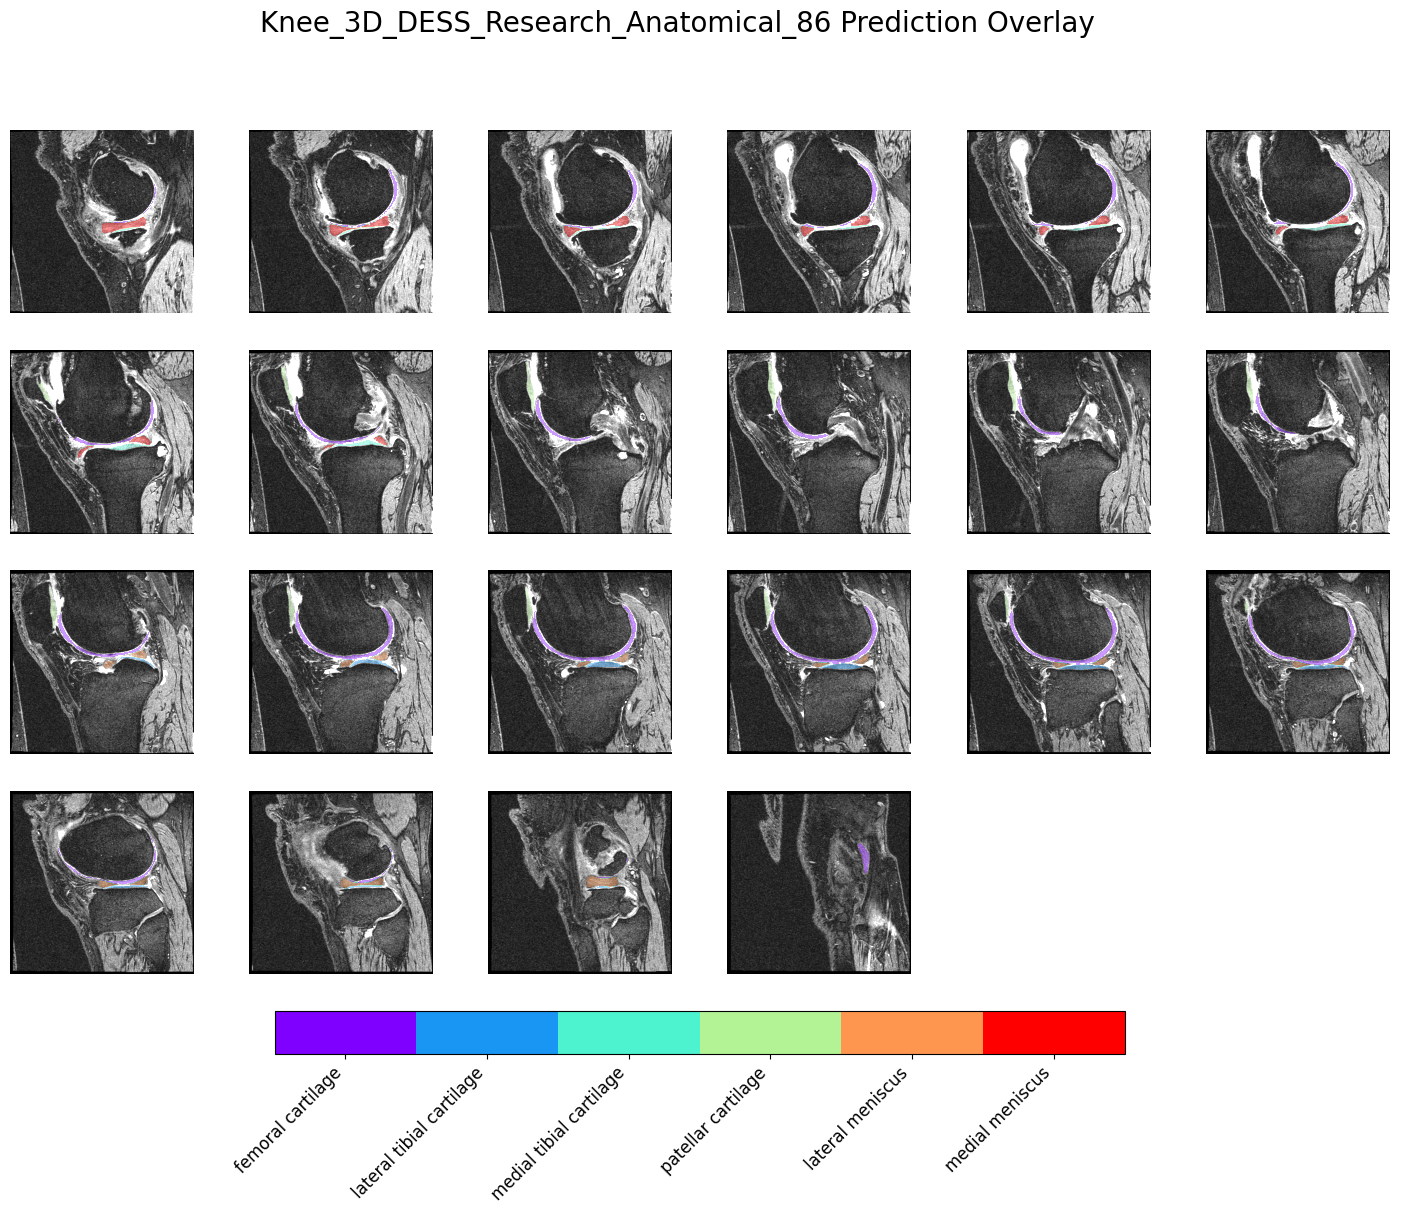

100%|██████████| 1/1 [01:20<00:00, 80.81s/it]


config_file: sam2_hiera_b+.yaml


  0%|          | 0/1 [00:00<?, ?it/s]

returning fig from plot_segmentation_overlay


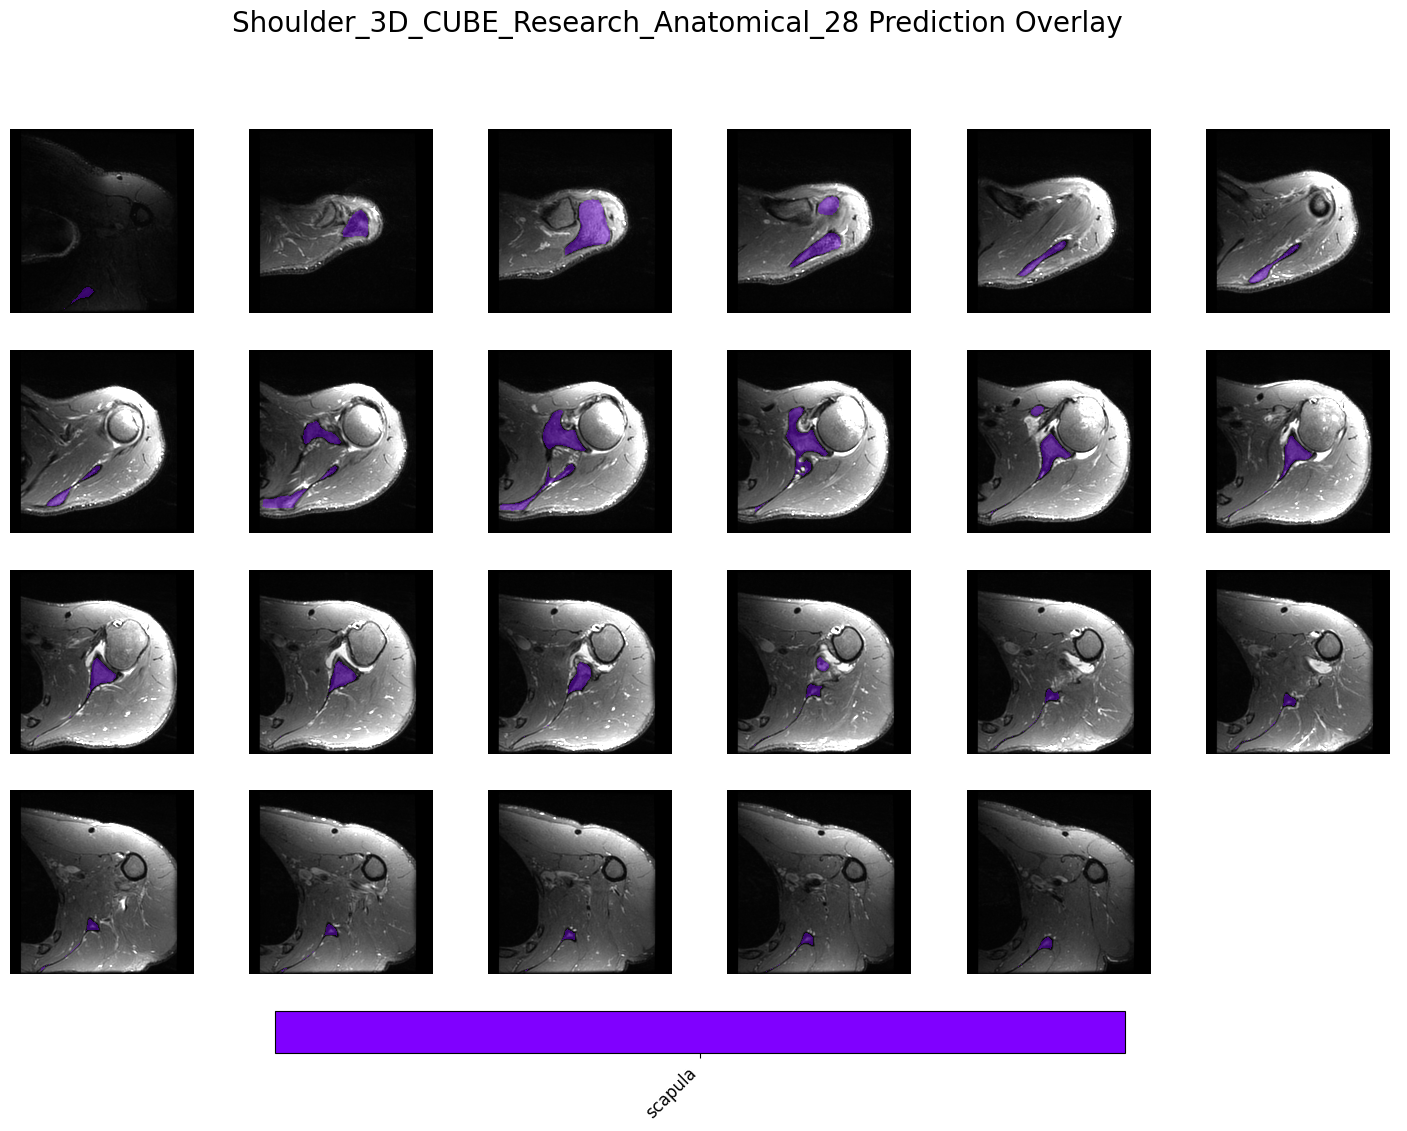

100%|██████████| 1/1 [01:17<00:00, 77.87s/it]


config_file: sam2_hiera_b+.yaml


  0%|          | 0/1 [00:00<?, ?it/s]

returning fig from plot_segmentation_overlay


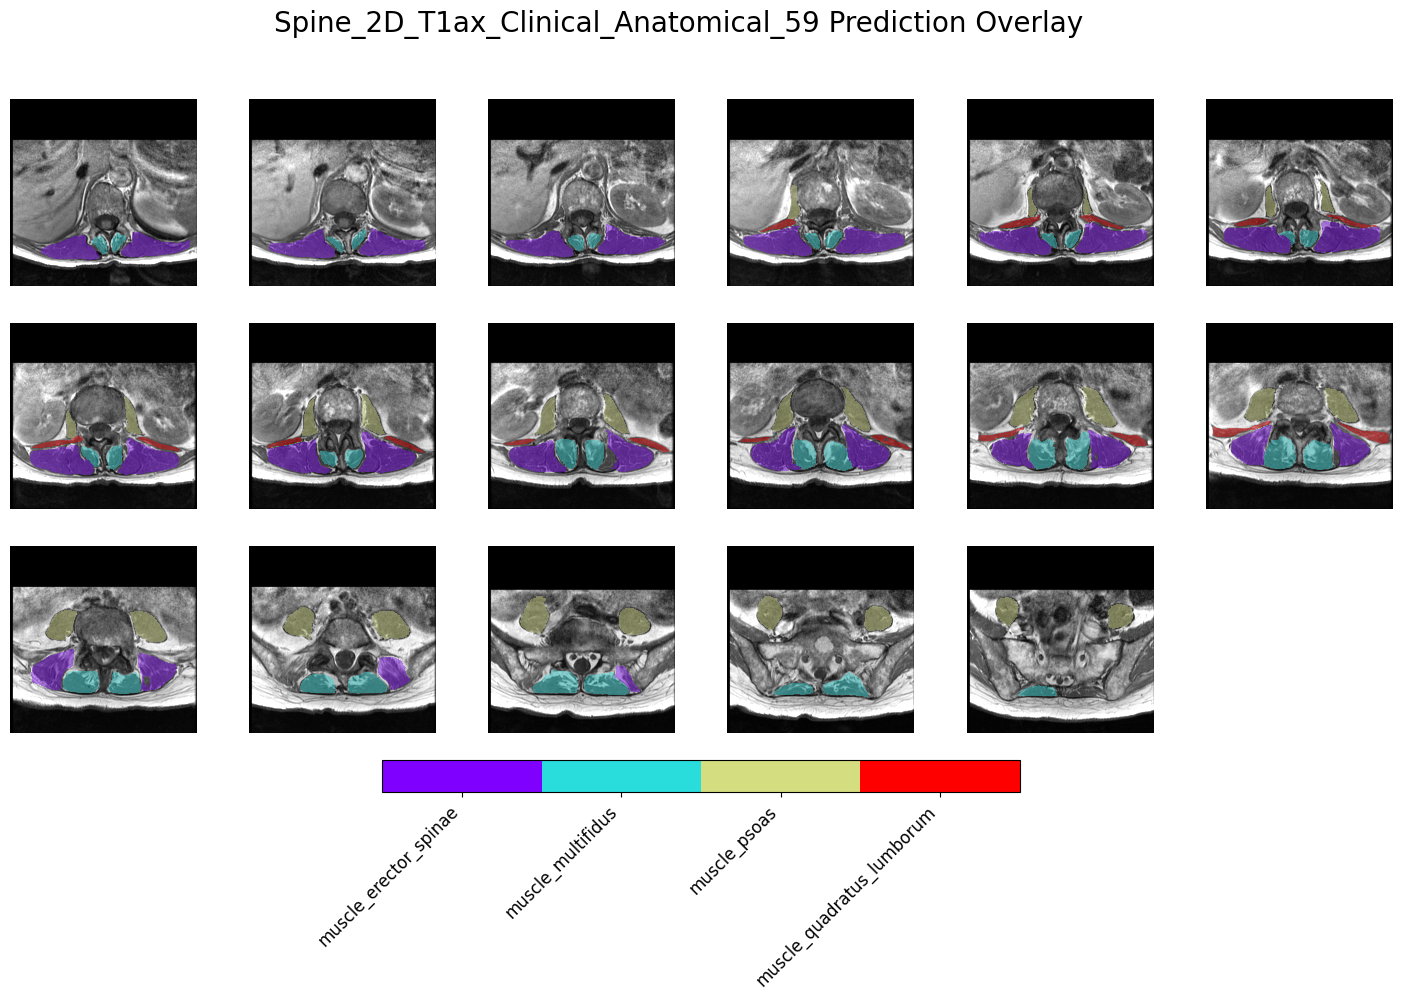

100%|██████████| 1/1 [00:42<00:00, 42.11s/it]


config_file: sam2_hiera_b+.yaml


  0%|          | 0/1 [00:00<?, ?it/s]

returning fig from plot_segmentation_overlay


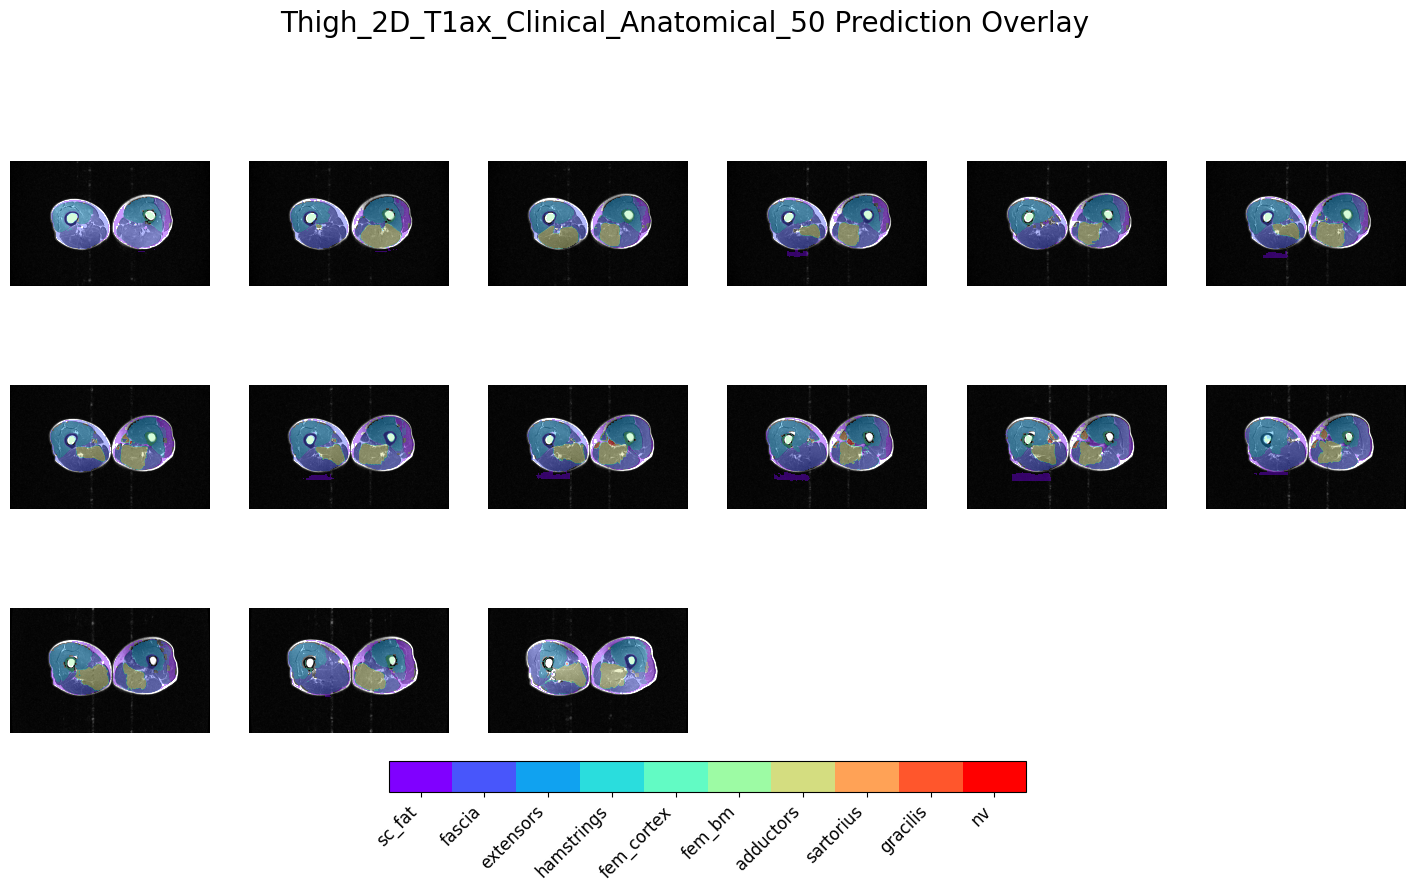

100%|██████████| 1/1 [00:35<00:00, 35.50s/it]


config_file: sam2_hiera_b+.yaml


  0%|          | 0/1 [00:00<?, ?it/s]

returning fig from plot_segmentation_overlay


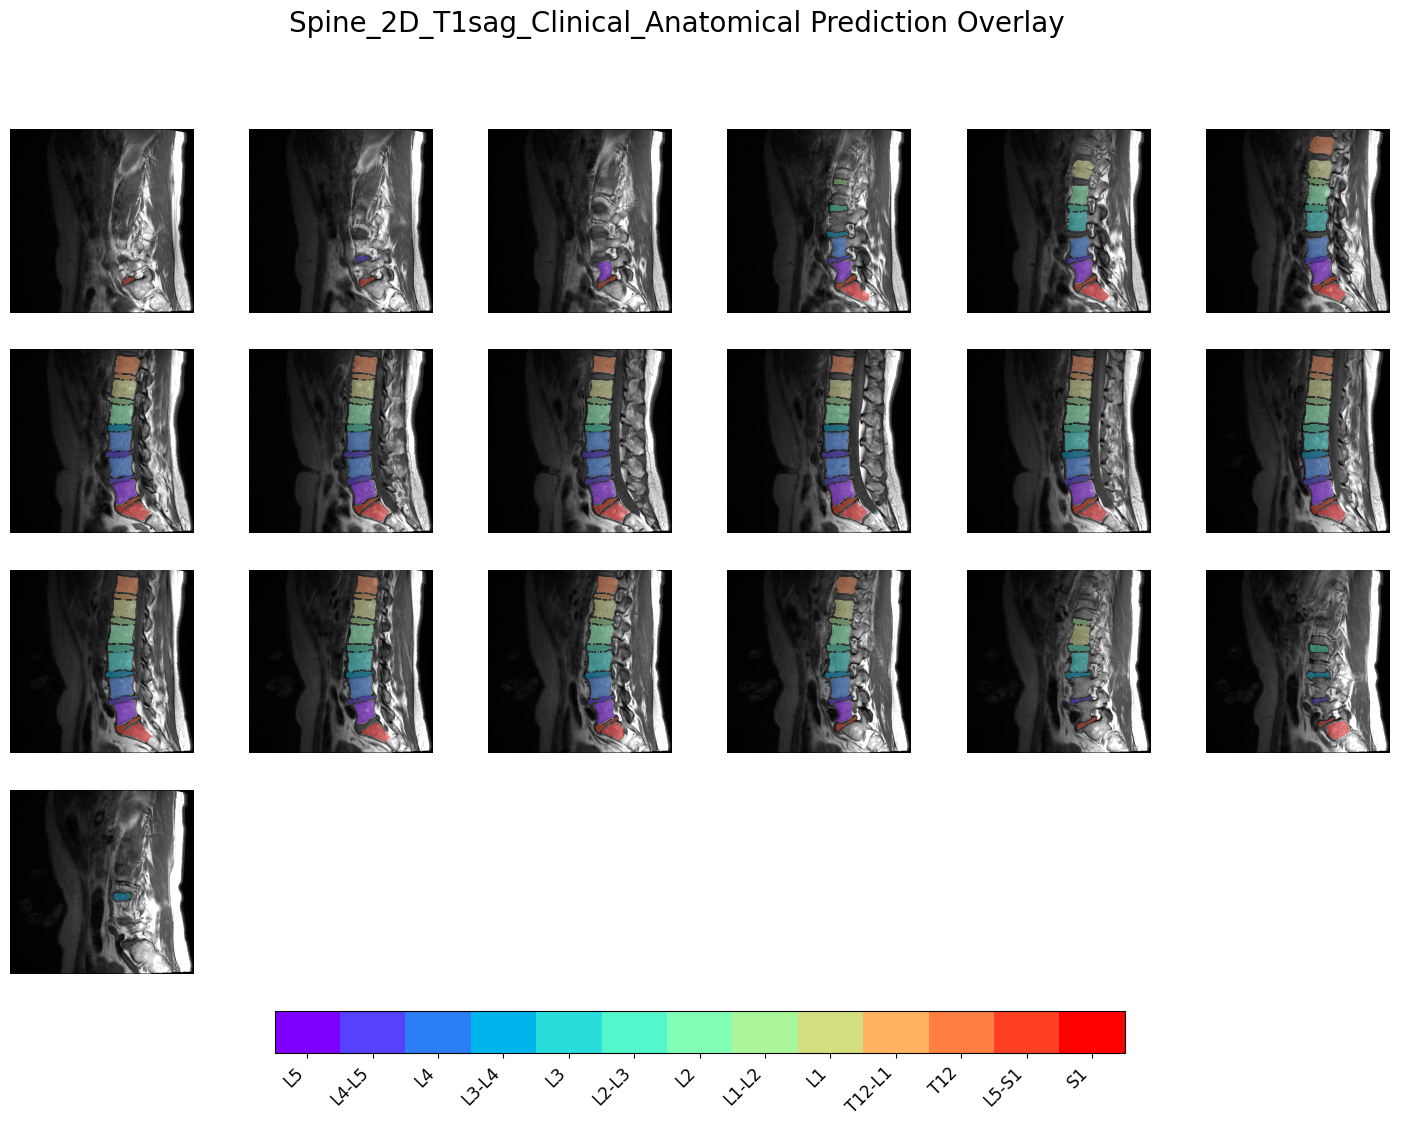

100%|██████████| 1/1 [00:24<00:00, 24.25s/it]


In [5]:

# Loop over each case, adjust the config, and run the process.
for case in cases:
    # Create a deep copy of the base configuration.
    config_copy = copy.deepcopy(base_config)
    
    # Update the data directory.
    config_copy["data"]["data_dir"] = case["data_dir"]
    
    # Update the output configuration for image color limits and task name.
    config_copy["output_cfg"]["img_clim"] = case["img_clim"]
    config_copy["output_cfg"]["task_name"] = f"Knee_{os.path.basename(case['data_dir'])}"
    
    # Update the object detection model fields.
    config_copy["models"]["obj_det"]["model_path"] = case["obj_det_model_path"]
    config_copy["models"]["obj_det"]["model_weights"] = case["obj_det_model_weights"]
    
    # Update the mask labels.
    config_copy["data"]["mask_labels"] = case["mask_labels"]
    
    # Run the autolabel process with the modified config.
    # autolabel.system_setup(config_copy, callback=notebook_callback, final_callback=final_callback)
    run_autolabel(config_copy, interactive=True, callback=notebook_callback, final_callback=final_callback)